In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Import Data

In [2]:
#d0=np.load('data1_2024-04-12_10-02-03.npz')
#d1=np.load('data1_2024-04-12_10-06-33.npz')
#d2=np.load('data1_2024-04-12_10-11-02.npz')

d0=np.load('data0.npz')
d1=np.load('data1.npz')
d2=np.load('data2.npz')

t_step = .05

zpos=[0]
nums0=d0['nums']
hs0=d0['hs']
rs0=d0['rs']
for ni in range(len(nums0)):
    for k in range(nums0[ni]):
        zpos.append(hs0[ni]*rs0[ni]/2)
        zpos.append(0)
        zpos.append(hs0[ni]*(1-rs0[ni]))
        zpos.append(0)
        zpos.append(hs0[ni]*rs0[ni]/2)
       
zpos0=np.cumsum(np.array(zpos))
inds0=d0['n_factors']

zpos=[0]
nums1=d1['nums']
hs1=d1['hs']
rs1=d1['rs']
for ni in range(len(nums1)):
    for k in range(nums1[ni]):
        zpos.append(hs1[ni]*rs1[ni]/2)
        zpos.append(0)
        zpos.append(hs1[ni]*(1-rs1[ni]))
        zpos.append(0)
        zpos.append(hs1[ni]*rs1[ni]/2)
zpos1=np.cumsum(np.array(zpos))
inds1=d1['n_factors']

zpos=[0]
nums2=d2['nums']
hs2=d2['hs']
rs2=d2['rs']
for ni in range(len(nums2)):
    for k in range(nums2[ni]):
        zpos.append(hs2[ni]*rs2[ni]/2)
        zpos.append(0)
        zpos.append(hs2[ni]*(1-rs2[ni]))
        zpos.append(0)
        zpos.append(hs2[ni]*rs2[ni]/2)
zpos2=np.cumsum(np.array(zpos))
inds2=d2['n_factors']

tv = d0['t_values']
kv = d0['k_values']

r0=np.load('results0.npz')
r1=np.load('results1.npz')
r2=np.load('results2.npz')

momentum_0=r0['momentum0m']
momentum_0L=r0['momentum0l']
edges0=r0['edges0']
boundaries0=r0['boundaries0']
mst0=r0['mst0']
lor0=r0['lor0']
poyn0=r0['poyn0']

edges1=r1['edges1']
boundaries1=r1['boundaries1']
mst1=r1['mst1']
lor1=r1['lor1']
poyn1=r1['poyn1']

edges2=r2['edges2']
boundaries2=r2['boundaries2']
mst2=r2['mst2']
lor2=r2['lor2']
poyn2=r2['poyn2']

def impulse(forces_t_pos,t_values,indices,t_step):
    return np.cumsum(np.sum(forces_t_pos[indices[0]:indices[1]],axis=0))*t_step

def impulses(forces_t_pos,t_values,edges,t_step):
    imp = []
    for i in range(len(edges)-1):
        imp+=[impulse(forces_t_pos,t_values,[edges[i],edges[i+1]],t_step)]
    imp+=[impulse(forces_t_pos,t_values,[edges[0],edges[-1]],t_step)]
    return imp

play0 = poyn0[2::5]+poyn0[0::5]+poyn0[4::5]
llay0 = lor0[2::5]
mlay0 = np.diff(mst0[0::5],axis=0)
imst0 = impulses(mlay0,tv,edges0,t_step)
ilor0 = impulses(llay0,tv,edges0,t_step)
ipv0 = impulses(play0,tv,edges0,t_step)

play1 = poyn1[2::5]+poyn1[0::5]+poyn1[4::5]
llay1 = lor1[2::5]
mlay1 = np.diff(mst1[0::5],axis=0)
imst1 = impulses(mlay1,tv,edges1,t_step)
ilor1 = impulses(llay1,tv,edges1,t_step)
ipv1 = impulses(play1,tv,edges1,t_step)

play2 = poyn2[2::5]+poyn2[0::5]+poyn2[4::5]
llay2 = lor2[2::5]
mlay2 = np.diff(mst2[0::5],axis=0)
imst2 = impulses(mlay2,tv,edges2,t_step)
ilor2 = impulses(llay2,tv,edges2,t_step)
ipv2 = impulses(play2,tv,edges2,t_step)

# Plots

## Miscellaneous

### Functions

In [3]:
colors = ['b','orange','g']
colors_med = ['blue'] # For plotting the crystals
colors_med1 = ['blue','red','green']
colors_med2 = ['blue','red','green','blue']

def plot_amps(ai,bi,xvals,time,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2)
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers*h_DBR],top_ys,bottom_ys,color='gray',alpha=0.2)
    #plt.plot(xvals,np.abs(ai)**2, label='|a|^2',c=cols[0])
    #plt.plot(xvals,np.abs(bi)**2, label='|b|^2',c=cols[1])
    #plt.plot(xvals,np.abs(ai+bi)**2, label='|a+b|^2',c=cols[2])
    plt.title('Optical System 2')#f'Intensity Across Layers t = {time:.2f} arb. units')
    plt.xlabel('Position (arb. units)') # A layer starts at the vacuum half before the medium portion
    #plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    #plt.legend()
    plt.grid()
    plt.show()

def amps3times(a_t_pos,b_t_pos,xvals,ts3,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1,bottom_y=0):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2)
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,np.abs(a_t_pos[ts3[0]])**2, label='|a|^2',c=cols[0])# t = {t_vals[t3d[0]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[0]])**2, label='|b|^2',c=cols[1])
    plt.plot(xvals,np.abs(a_t_pos[ts3[0]]+b_t_pos[ts3[0]])**2, label='|a+b|^2',c=cols[2])
    
    plt.plot(xvals,np.abs(a_t_pos[ts3[1]])**2, ls = '-.',c=cols[0])#, label=f'|a|^2 t = {t_vals[t3d[1]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[1]])**2, ls = '-.',c=cols[1])#, label='|b|^2')
    plt.plot(xvals,np.abs(a_t_pos[ts3[1]]+b_t_pos[ts3[1]])**2, ls = '-.',c=cols[2])#, c=colors[2], label='|a+b|^2')
    
    plt.plot(xvals,np.abs(a_t_pos[ts3[2]])**2, ls = '--',c=cols[0])#, label=f'|a|^2 t = {t_vals[t3d[2]]}')
    plt.plot(xvals,np.abs(b_t_pos[ts3[2]])**2, ls = '--',c=cols[1])#, label='|b|^2')
    plt.plot(xvals,np.abs(a_t_pos[ts3[2]]+b_t_pos[ts3[2]])**2, ls = '--',c=cols[2])#, c=colors[2], label='|a+b|^2')
    
    plt.title(f'Intensity in Crystals')
    plt.xlabel('Position (arb. units)') # A layer starts at the vacuum half before the medium portion
    plt.ylabel('Intensity (arb. units)')
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()
    plt.grid()
    plt.show()

#np.cumsum(f_dens_pos.T,axis=0)
def plot_mstimps(mimp1,mimp2,xvals,time,num_elements,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Impulse Surface Densities (arb. units)') #Force/Impulse SD
    plt.title(f'(MST) Z-Impulse Surface Densities in Medium Layers t = {time:.2f} arb. units') #Z-Force Surface Densities (SD)
    plt.plot(xvals,mimp1,label='OS1',c=cols[0])
    plt.plot(xvals,mimp2,label='OS2',c=cols[1])
    #plt.plot(xvals,impsd_mst_pos,c='purple')#,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    #np.cumsum(f_dens_pos.T,axis=0)
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()#loc='upper left')
    plt.grid()
    plt.plot()

def plot_mstforcez(fdp1,fdp2,fdp3,xvals,time1,time2,time3,num_elements,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    #f_dens_pos = np.diff(z_mom_flux_pos)
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Momentum Flux (arb. units)') #Force/Impulse SD
    plt.title(f'(MST) Z-Momentum Flux in Medium Layers') #Z-Force Surface Densities (SD)
    plt.plot(xvals,fdp1,label=f't = {time1:.2f} arb. units')
    plt.plot(xvals,fdp2,label=f't = {time2:.2f} arb. units')
    plt.plot(xvals,fdp3,label=f't = {time3:.2f} arb. units')
    #plt.plot(xvals,impsd_mst_pos,c='purple')#,label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    #np.cumsum(f_dens_pos.T,axis=0)
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.legend()#loc='upper left')
    plt.grid()
    plt.plot()

#np.cumsum(layerforces.T,axis=0)
def plot_lorentz1imps(layerforces1,layerforces2,xvals,time,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Z-Impulse Surface Densities in Medium Layers t = {time:.2f} time units')
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Impulse Surface Density (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges[:-1]:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,layerforces1,label='OS1',c=cols[0])
    plt.plot(xvals,layerforces2,label='OS2',c=cols[1])
    #plt.plot(xvals,impsd_lor_pos,c=cols[1])#label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.grid()
    plt.legend()#loc='upper left')
    plt.show()

def plot_lorentzforcez1(layerforces1,layerforces2,layerforces3,xvals,time1,time2,time3,num_elements,h_DBR,n_DBR_pers=0,cols=colors,cols_med=colors_med1,top_y=1.5,bottom_y=-1.6):
    plt.figure(figsize=(10, 4))
    edges = np.cumsum(np.array(num_elements))
    edgelocs = np.array([0, num_elements[0]])
    for i in range(len(num_elements)-1):
         edgelocs= np.append(edgelocs, [edges[i],edges[i]+num_elements[i+1]])
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    plt.title(f'(Lorentz) Force Surface Densities in Medium Layers')
    plt.xlabel('Position (arb. units)')
    plt.ylabel('Force Surface Density (arb. units)')
    for n in range(len(num_elements)):
        plt.fill_between([edgelocs[2*n],edgelocs[2*n+1]],top_ys,bottom_ys,color=cols_med[n],alpha=0.2) 
    for loc in edges:
        plt.axvline(loc,ls='--',c='k')
    if n_DBR_pers != 0:
        plt.axvline(edges[-1],lw=3,c='k')
        plt.fill_between([edgelocs[-1],edgelocs[-1]+h_DBR*n_DBR_pers],top_ys,bottom_ys,color='gray',alpha=0.2)
    plt.plot(xvals,layerforces1,label=f't = {time1:.2f} arb. units')
    plt.plot(xvals,layerforces2,label=f't = {time2:.2f} arb. units')
    plt.plot(xvals,layerforces3,label=f't = {time3:.2f} arb. units')
    #plt.plot(xvals,impsd_lor_pos,c=cols[1])#label= f'Cumulative Z-Impulse SD at t = {time:.2f} time units',c=cols[1])
    plt.ylim(bottom_y-0.02,top_y+0.02)
    plt.xlim(0,15.4)
    plt.grid()
    plt.legend()#loc='upper left')
    plt.show()

### Execution

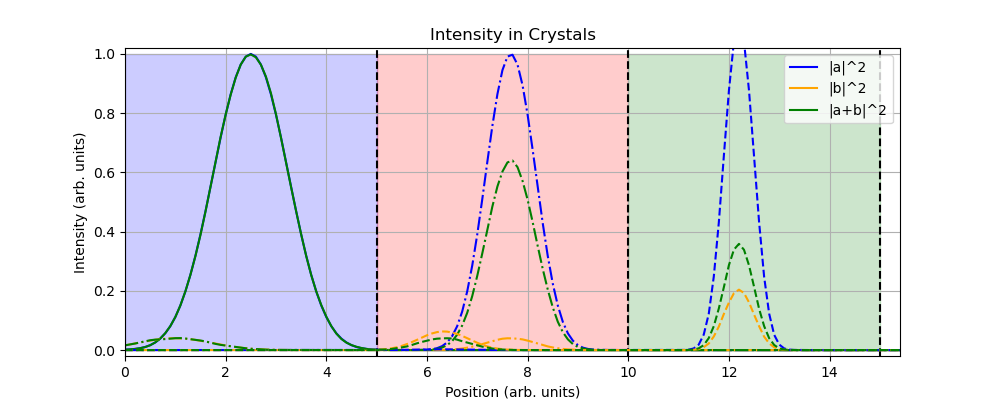

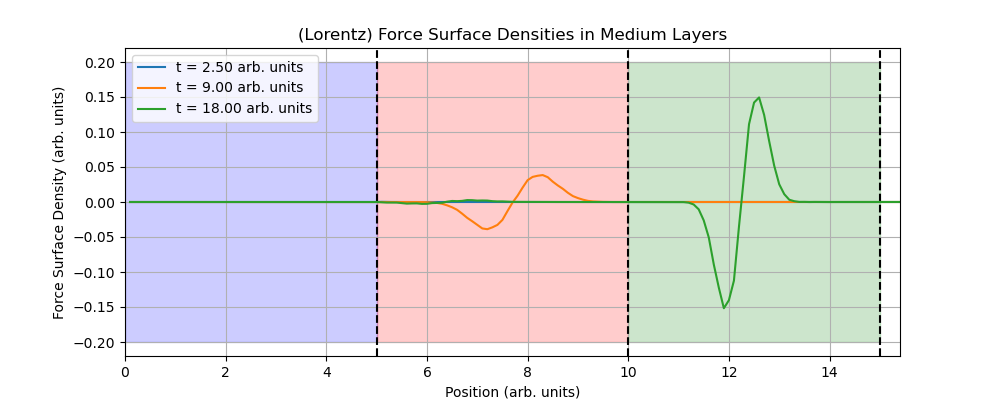

NameError: name 'MST' is not defined

In [4]:
%%time
#time domain, intensity
c=1;
mt=np.exp(-1j * np.outer(tv,kv) * c)*d1['gauss']
norm = np.sum(np.abs(mt[0]))
a_k = d1['ai_pol_k']#[:,0::5]
b_k = d1['bi_pol_k']#[:,0::5]
a_t=((mt@a_k)/norm)[:,0::5]
b_t=((mt@b_k)/norm)[:,0::5]
pos = zpos1[0::5]
boundaries = boundaries1
nums = nums1
hs = hs1

ta = 80+10 # 2 seconds
tb = 220 # 9 seconds
tc = 400 # 18 seconds
tdbr = 560 # 26 seconds
#t=180

#plot_amps(a_t[t],b_t[t],pos,tv[t],nums*hs,hs[-1],n_DBR_pers=0,cols=colors,cols_med=colors_med2)
ts3 = [ta,tb,tc]
amps3times(a_t,b_t,pos,ts3,nums[:-1]*hs[:-1],hs[-1],n_DBR_pers=0,cols_med=colors_med2)
t=-1
#np.cumsum(llay1.T,axis=0)[t]
LF1 = lor1[2::5].T
LF2 = lor2[2::5].T
plot_lorentzforcez1(LF1[ta],LF1[tb],LF1[tc],pos[1:],tv[ta],tv[tb],tv[tc],nums[:-1]*hs[:-1],hs[-1],n_DBR_pers=0,
                    cols_med=colors_med1,top_y=0.2,bottom_y=-0.2)
MST1 = (np.diff(mst1[0::5].T))
MST2 = (np.diff(mst2[0::5].T))
plot_mstforcez(MST[ta],MST[tb],MST[tc],pos[1:],tv[ta],tv[tb],tv[tc],nums[:-1]*hs[:-1],n_DBR_pers=0,cols=colors,cols_med=colors_med1,
            top_y=.2,bottom_y=-.2)

plot_mstimps(np.cumsum(MST1,axis=0)[-1]*t_step,np.cumsum(MST2,axis=0)[-1]*t_step,pos[1:],tv[-1],nums[:-1]*hs[:-1],
             n_DBR_pers=0,cols=colors,cols_med=colors_med1)

plot_lorentz1imps(np.cumsum(LF1,axis=0)[-1]*t_step,np.cumsum(LF2,axis=0)[-1]*t_step,pos[1:],tv[-1],nums[:-1]*hs[:-1],hs[-1],
             n_DBR_pers=0,cols=colors,cols_med=colors_med1)

In [5]:
boundaries1

array([ 5.        , 10.        , 15.        , 58.64306287])

## Impulse Over Time

### Single

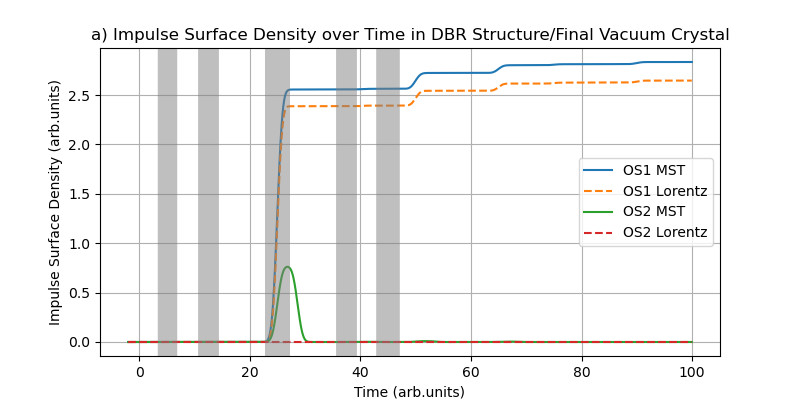

In [6]:
i = 2
plt.figure(figsize=(8,4))
int_regions = ['Crystal 1','Crystal 2','DBR Structure/Final Vacuum Crystal','Whole System']
p0 = momentum_0
plt.plot(tv,(imst1[i]+ipv1[i])/p0,label='OS1 MST')
plt.plot(tv,(ilor1[i])/p0,ls='--',label='OS1 Lorentz')
plt.plot(tv,(imst2[i]+ipv2[i])/p0,label='OS2 MST')
plt.plot(tv,(ilor2[i])/p0,ls='--',label='OS2 Lorentz')
plt.axvline(5,lw=14,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
plt.axvline(12.5,lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
plt.axvline(25,lw=18,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
plt.axvline(37.4,lw=15,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
plt.axvline(45,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
plt.ylabel('Impulse Surface Density (arb.units)')
plt.xlabel('Time (arb.units)')
plt.title('a) Impulse Surface Density over Time in '+int_regions[i])
plt.grid()
plt.legend()
plt.show()

### Stacked

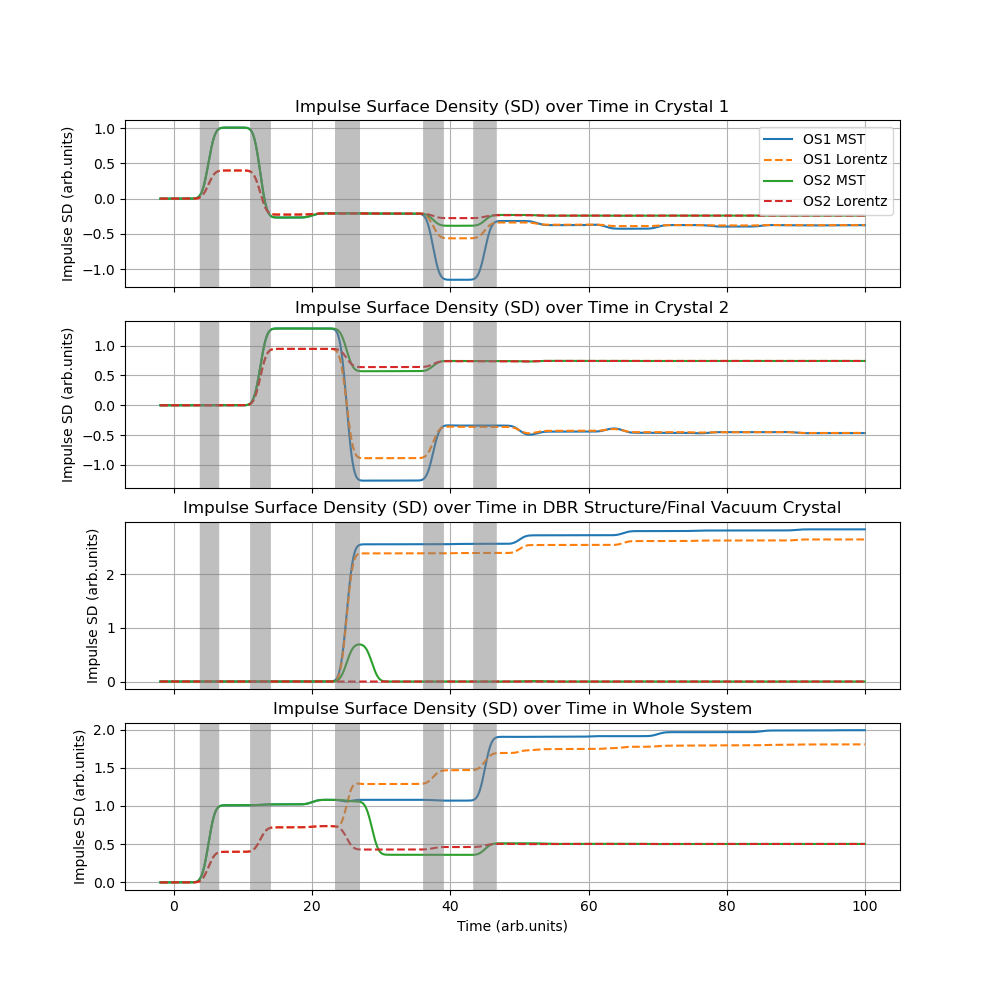

In [9]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
int_regions = ['Crystal 1','Crystal 2','DBR Structure/Final Vacuum Crystal','Whole System']
p0=momentum_0
for i in range(len(int_regions)):
    axs[i].set_title('Impulse Surface Density (SD) over Time in '+int_regions[i])
    axs[i].set_ylabel('Impulse SD (arb.units)')
    axs[i].plot(tv,(imst1[i]-ipv1[i])/p0,label='OS1 MST')
    axs[i].plot(tv,(ilor1[i])/p0,ls='--',label='OS1 Lorentz')
    axs[i].plot(tv,(imst2[i]-ipv2[i])/p0,label='OS2 MST')
    axs[i].plot(tv,(ilor2[i])/p0,ls='--',label='OS2 Lorentz')
    axs[i].axvline(5,lw=14,c='gray',alpha=0.5) # Pulse enters first crystal (first interface)
    axs[i].axvline(12.5,lw=15,c='gray',alpha=0.5) # Pulse enters second crystal (second interface)
    axs[i].axvline(25,lw=18,c='gray',alpha=0.5) # Pulse hits mirror/exits system (third interface)
    axs[i].axvline(37.4,lw=15,c='gray',alpha=0.5) # Main reflected pulse re-enters crystal 1
    axs[i].axvline(45,lw=17,c='gray',alpha=0.5) # Main reflected pulse exits system going left
    axs[i].grid()
    if i == 0:
        axs[i].legend() #(loc='upper right')
    if i == 3:
        axs[i].set_xlabel('Time (arb.units)')
plt.show()